# add_damage_record.ipynb
Add a new damages record to the database.

In [1]:
%matplotlib widget
import ipympl
import matplotlib.pyplot as plt

import sqlite3
from icecream import ic 
import numpy as np
import shapely
from shapely import wkt
from pyefd import elliptic_fourier_descriptors, calculate_dc_coefficients, reconstruct_contour
import cv2




In [2]:
db_path = 'new.db'
image_id = 1
tree_id = 1
order = 20

In [3]:
# Open a database with images and trees tables populated
conn = sqlite3.connect(db_path)   
conn.enable_load_extension(True)
conn.load_extension('mod_spatialite')
cursor = conn.cursor()

In [4]:
import ipywidgets as widgets
widgets.IntSlider(value=50)


IntSlider(value=50)

In [5]:
!jupyter notebook --version

7.5.6


In [6]:
cursor.execute(f'SELECT AsWKT(tree_poly) FROM trees WHERE image_id={image_id}')
tree_wkts = cursor.fetchall()
ic(tree_wkts)
ic(len(tree_wkts))


ic| tree_wkts: [('POLYGON((486 -677,486 -682,485 -683,485 -687,484 -688,484 -689,482 -691,481 '
                 '-691,478 -694,478 -706,477 -707,477 -718,479 -720,479 -721,482 -724,482 '
                 '-725,483 -725,486 -728,486 -729,489 -732,489 -733,490 -734,490 -735,491 '
                 '-736,491 -740,490 -741,489 -741,488 -742,486 -742,485 -743,475 -743,474 '
                 '-744,473 -744,474 -744,475 -745,476 -745,477 -746,478 -746,479 -747,483 '
                 '-747,484 -748,486 -748,487 -749,490 -749,491 -750,493 -750,495 -752,495 '
                 '-753,496 -754,496 -757,495 -758,495 -759,493 -761,493 -762,491 -764,490 '
                 '-764,489 -765,489 -766,488 -767,487 -767,486 -768,486 -769,484 -771,484 '
                 '-772,483 -773,483 -774,482 -775,482 -778,479 -781,478 -781,477 -782,476 '
                 '-782,473 -785,473 -788,472 -789,472 -791,471 -792,471 -799,470 -800,470 '
                 '-806,475 -811,476 -811,477 -812,478 -812,479 -813,480 -813

2

In [7]:
wkt_string = tree_wkts[0][0]  # Get the WKT string from the first row
ic(wkt_string)

# # 1. Load the WKT into a Shapely geometry object
# polygon = wkt.loads(wkt_string)

# # 2. Extract the exterior coordinates and convert to a NumPy array
# # coords_array = np.array(polygon.exterior.coords)





    # tree_contour = np.array(tree_poly_str.exterior.coords).astype(np.int32)
    # tree_contour = np.abs(tree_contour) # Ensure all coordinates are positive
    # ic(tree_contour)
    # ic(tree_contour.dtype)
    # ic(type(tree_contour))
    # len(tree_contour)for tree_wkt in tree_poly[0]:
    
    # Use Shapely to convert the WKB binary to a polygon and extract the contour coordinates
    # 1. Parse WKT to standard Shapely objects
    
    # geometries = shapely.from_wkt(wkt_list)

    
# 1. Load the WKT into a Shapely geometry object
polygon = wkt.loads(wkt_string)

# 2. Extract the exterior coordinates and convert to a NumPy array
coords_array = np.array(polygon.exterior.coords)
coords_array = np.abs(coords_array)  # Ensure all coordinates are positive

ic(coords_array)
ic(coords_array.shape);

    
    


ic| wkt_string: 'POLYGON((486 -677,486 -682,485 -683,485 -687,484 -688,484 -689,482 -691,481 -691,478 -694,478 -706,477 -707,477 -718,479 -720,479 -721,482 -724,482 -725,483 -725,486 -728,486 -729,489 -732,489 -733,490 -734,490 -735,491 -736,491 -740,490 -741,489 -741,488 -742,486 -742,485 -743,475 -743,474 -744,473 -744,474 -744,475 -745,476 -745,477 -746,478 -746,479 -747,483 -747,484 -748,486 -748,487 -749,490 -749,491 -750,493 -750,495 -752,495 -753,496 -754,496 -757,495 -758,495 -759,493 -761,493 -762,491 -764,490 -764,489 -765,489 -766,488 -767,487 -767,486 -768,486 -769,484 -771,484 -772,483 -773,483 -774,482 -775,482 -778,479 -781,478 -781,477 -782,476 -782,473 -785,473 -788,472 -789,472 -791,471 -792,471 -799,470 -800,470 -806,475 -811,476 -811,477 -812,478 -812,479 -813,480 -813,482 -815,483 -815,486 -818,486 -819,487 -820,487 -821,486 -822,485 -822,484 -821,477 -821,477 -822,479 -822,480 -823,482 -823,484 -825,485 -825,486 -826,487 -826,488 -827,490 -827,491 -828,493 -828,49

In [8]:
# img_width, img_height, _ = img.shape

original_contour = coords_array

num_harmonics=order

original_contour = np.array(original_contour, dtype=np.float64).reshape(-1, 2)
ic(original_contour)

# 1. Extract descriptors (keep normalize=False to retain native spatial details)
coeffs = elliptic_fourier_descriptors(original_contour, order=num_harmonics, normalize=False)
ic(coeffs)

# 2. Extract DC spatial tracking offsets
dc_coeffs = calculate_dc_coefficients(original_contour)
ic(dc_coeffs)

# 3. Generate raw reconstruction (matching original row length for point parity)
reconstructed_contour = reconstruct_contour(
    coeffs, 
    locus=dc_coeffs, 
    num_points=len(original_contour)
)
ic(reconstructed_contour)

# # ic(original_contour.astype(np.int32));

# img = np.zeros((img.shape[0], img.shape[1], 3), dtype=np.uint8)
# cv2.polylines(img, pts=[original_contour.astype(np.int32)], isClosed=True, color=(255, 255, 255), thickness=2)
# cv2.polylines(img, pts=[reconstructed_contour.astype(np.int32)], isClosed=True, color=(0,255,0), thickness=2)
# plt.imshow(img[600:1000, 250:750]);

ic| original_contour: array([[486., 677.],
                             [486., 682.],
                             [485., 683.],
                             ...,
                             [488., 678.],
                             [487., 678.],
                             [486., 677.]], shape=(1084, 2))
ic| coeffs: array([[ 6.22123364e+01, -2.21524732e+01, -5.83255301e+02,
                    -4.36984195e+01],
                   [-2.81761776e+01, -7.78865682e+00,  3.20948788e+01,
                     9.93513444e+00],
                   [-1.71260475e-01, -1.68758580e+01, -4.10944452e+01,
                    -5.89214217e+00],
                   [-8.38095469e+00, -6.88731309e+00,  1.45348145e+01,
                     1.04286413e+01],
                   [-9.70108745e-01, -7.59245191e+00, -1.70403964e+01,
                    -1.81209180e+00],
                   [-2.51362275e+00,  2.83122038e+00,  1.01583167e+00,
                     6.38713758e+00],
                   [-6.34559576e-01,

array([[480.31974521, 694.87261392],
       [480.14062232, 694.93119957],
       [480.06525034, 695.15043333],
       ...,
       [481.0056223 , 695.24231877],
       [480.60694613, 694.97614296],
       [480.31974521, 694.87261392]], shape=(1084, 2))

ic| img: array([[[150, 190, 222],
                 [150, 190, 222],
                 [150, 190, 222],
                 ...,
                 [154, 191, 226],
                 [154, 191, 226],
                 [154, 191, 226]],
         
                [[150, 190, 222],
                 [150, 190, 222],
                 [150, 190, 222],
                 ...,
                 [154, 191, 226],
                 [154, 191, 226],
                 [154, 191, 226]],
         
                [[150, 190, 222],
                 [150, 190, 222],
                 [150, 190, 222],
                 ...,
                 [154, 191, 226],
                 [154, 191, 226],
                 [154, 191, 226]],
         
                ...,
         
                [[186, 216, 238],
                 [186, 216, 238],
                 [186, 216, 238],
                 ...,
                 [193, 224, 243],
                 [194, 223, 243],
                 [194, 223, 243]],
         
                [[186

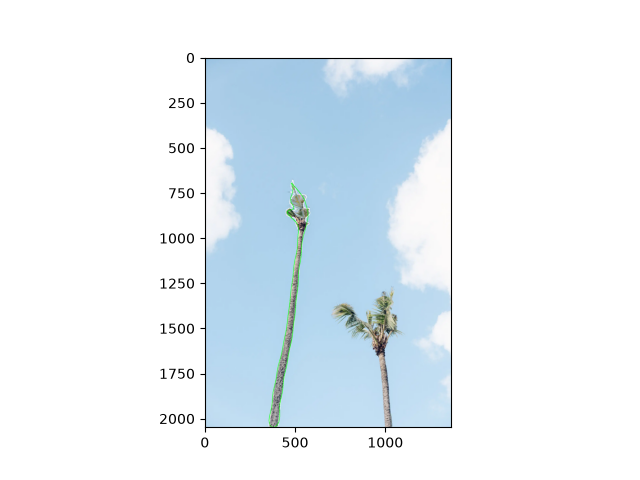

In [10]:
cursor.execute(f'SELECT image_path FROM images WHERE image_id = {image_id}')
image_path = cursor.fetchone()
img = cv2.imread(image_path[0])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
ic(img)

cv2.polylines(img, pts=[original_contour.astype(np.int32)], isClosed=True, color=(255, 255, 255), thickness=2)
ic(img)

cv2.polylines(img, pts=[reconstructed_contour.astype(np.int32)], isClosed=True, color=(0,255,0), thickness=2)

# 4. Initialize the figure and axes for the widget window
fig, ax = plt.subplots()

# 5. Render the image inside the interactive widget frame
ax.imshow(img)
plt.show()

